In [1]:
import numpy as np
import pandas as pd
from loco_methods import *
from ml_models import *
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

Data Generating

In [2]:
N = 200 # Training data sample size
M = 50 # Number of features
N1 = 10000 # Test data sample size
beta = [2.5, 2.1, 1.7, 1.3, 1] # For signal features. 5 signal features and 45 noise features

np.random.seed(100)

X_train =  np.random.normal(0, 1, (N, M))
X_test =  np.random.normal(0, 1, (N1, M))

beta = np.append(np.array(beta), np.array([0]*(M-len(beta))))

Y_train = np.dot(X_train,beta)+np.random.normal(0, 1, N)
Y_test = np.dot(X_test,beta)+np.random.normal(0, 1, N1)

scaler = StandardScaler()
Y_train = scaler.fit_transform(Y_train.reshape(-1,1))
Y_test = scaler.transform(Y_test.reshape(-1,1))
Y_train = Y_train.reshape(-1)
Y_test = Y_test.reshape(-1)

LOCO Methods

In [3]:
ml_model =  RidgeReg # Base model: Ridge(fit_intercept = False, alpha=0.001)
lossfunc = "sq" # Loss function
alpha = 0.1 # Significance level

n = int(N**0.8) # Minipatch size for observations
m = int(4*np.log(M)) # Minipatch size for features
Kb = [2000, 2000, 2000, 2000, 10000] # Number of minipatches for each iteration

indep_delta = 0.9 # Upper bound for sampling probability
samp_prob = np.array([1/M] * M) # Initial sampling probability

### LOCO-AdaMP
locoadamp = LOCOAdaMP(X_train, Y_train, X_test, Y_test, n, m, Kb, ml_model, samp_prob, alpha, lossfunc, indep_delta)

In [4]:
K_locomp = sum(Kb) # Number of minipatches

### LOCO-MP
locomp = LOCOMP(X_train,Y_train,X_test,Y_test, n, m, K_locomp, ml_model, alpha, lossfunc)

In [5]:
ml_model = RidgeCVReg # Base model: RidgeCV(alphas=np.logspace(-3, 1, 50), fit_intercept = False, cv = 5) 

ratio = 0.5 # Ratio of training inference split

### LOCO-Split
locosplit = LOCOSplit(X_train, Y_train, X_test, Y_test, ml_model, ratio, alpha, lossfunc)

Result

In [6]:
# Importance score
adamp_target = np.zeros((2, len(Kb)))
for b in range(len(Kb)):
    adamp_target[0][b] = locoadamp[b]['target'][0] # Feature 1, a signal feature
    adamp_target[1][b] = locoadamp[b]['target'][5] # Feature 6, a noise feature
iteration = range(1, len(Kb) + 1)
target = pd.DataFrame({'iteration':iteration, 'target1':adamp_target[0], 'target6':adamp_target[1]})

# Test error
locoadamp_prederr = locoadamp[len(Kb)-1]['err2'][0].mean()
locomp_prederr = locomp['err2'][0].mean()
locosplit_prederr = locosplit['err2'][0].mean()
loco = ["LOCO-AdaMP", "LOCO-MP", "LOCO-Split"]
pred_err = [locoadamp_prederr, locomp_prederr, locosplit_prederr]
pred_error = pd.DataFrame({'LOCO':loco, 'pred_error':pred_err})


# Confidence interval
adamp_ci_center = [0] * M
adamp_ci_err = [0] * M
mp_ci_center = [0] * M
mp_ci_err = [0] * M
split_ci_center = [0] * M
split_ci_err = [0] * M

for i in range(M):
    adamp_ci_center[i]=0.5*(locoadamp[len(Kb)-1]['inf'][i][2]+locoadamp[len(Kb)-1]['inf'][i][3])
    adamp_ci_err[i]=0.5*(locoadamp[len(Kb)-1]['inf'][i][3]-locoadamp[len(Kb)-1]['inf'][i][2])

    mp_ci_center[i]=0.5*(locomp['inf'][i][2]+locomp['inf'][i][3])
    mp_ci_err[i]=0.5*(locomp['inf'][i][3]-locomp['inf'][i][2])

    split_ci_center[i]=0.5*(locosplit['inf'][i][2]+locosplit['inf'][i][3])
    split_ci_err[i]=0.5*(locosplit['inf'][i][3]-locosplit['inf'][i][2])

locoadamp_ci = pd.DataFrame({'feature':list(range(1,M+1)), 'ci_center':adamp_ci_center, 'ci_err':adamp_ci_err})
locomp_ci = pd.DataFrame({'feature':list(range(1,M+1)), 'ci_center':mp_ci_center, 'ci_err':mp_ci_err})
locosplit_ci = pd.DataFrame({'feature':list(range(1,M+1)), 'ci_center':split_ci_center, 'ci_err':split_ci_err})

Figures

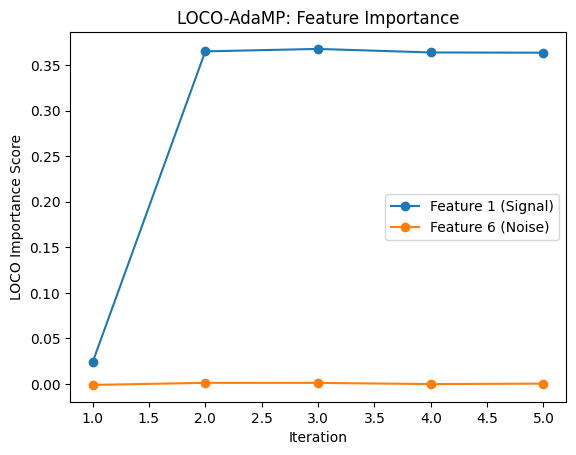

In [7]:
# LOCO-AdaMP feature importance
plt.plot(target['iteration'],target['target1'],linestyle='-', marker='o', label = "Feature 1 (Signal)")
plt.plot(target['iteration'],target['target6'],linestyle='-', marker='o', label = "Feature 6 (Noise)")
plt.xlabel("Iteration")
plt.ylabel("LOCO Importance Score")
plt.title("LOCO-AdaMP: Feature Importance")
plt.legend(loc='best')
plt.show()

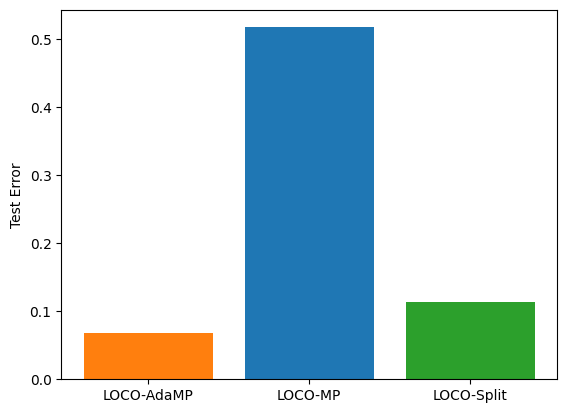

In [8]:
# Test error comparison
plt.bar(pred_error["LOCO"], pred_error["pred_error"], color=['#ff7f0e', '#1f77b4', '#2ca02c'])
plt.ylabel('Test Error')
plt.show()

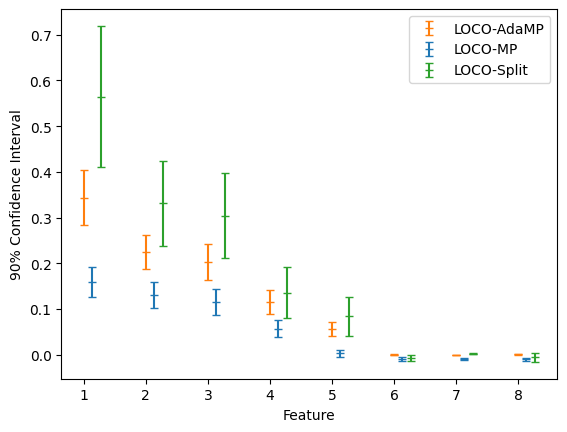

In [9]:
# Confidence interval comparison
plt.errorbar(x = locoadamp_ci["feature"][:8], y=locoadamp_ci['ci_center'][:8], yerr=locoadamp_ci['ci_err'][:8], color ='#ff7f0e', capsize=3, marker="_", label = f'LOCO-AdaMP', linestyle="None")
plt.errorbar(x = locomp_ci["feature"][:8]+0.135, y=locomp_ci['ci_center'][:8], yerr=locomp_ci['ci_err'][:8], color ='#1f77b4', capsize=3, marker="_", label = f'LOCO-MP', linestyle="None")
plt.errorbar(x = locosplit_ci["feature"][:8]+2*0.135, y=locosplit_ci['ci_center'][:8], yerr=locosplit_ci['ci_err'][:8], color ='#2ca02c', capsize=3, marker="_", label = f'LOCO-Split', linestyle="None")
plt.xlabel("Feature")
plt.ylabel("90% Confidence Interval")
plt.legend(loc='best')
plt.show()